# Side-by-side comparison of all metacell backends

Each backend in the [metacell-zoo](index.md) was developed by a different
group with different assumptions.  This notebook runs all six
always-available backends (`seacells`, `metaq`, `supercell`, `kmeans`,
`random`, `geosketch`) on the same pancreas data and ranks them by:

- **runtime** — how long does it take?
- **purity** — fraction of each metacell that belongs to a single celltype
- **rigor_score** — mcRigor's composite score (higher = better)
- **dubious_rate** — fraction of cells in heterogeneous metacells
- **compactness** — mean distance from cells to their metacell centroid in
  PCA space

`ov.single.compare_metacell_backends` runs all of this in one call.

## 1. Setup

In [1]:
# Standard imports + omicverse defaults.
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import omicverse as ov
import scvelo as scv      # only used for the demo dataset

ov.plot_set()

🔬 Starting plot initialization...
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.0   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 2. Load and preprocess

In [2]:
# Pancreas scRNA-seq (Bastidas-Ponce et al. 2019). Standard omicverse
# preprocess flow: qc -> preprocess -> scale -> pca -> neighbors -> umap.
adata = scv.datasets.pancreas()
adata = ov.pp.qc(adata,
                 tresh={'mito_perc': 0.20, 'nUMIs': 500, 'detected_genes': 250},
                 mt_startswith='mt-')
adata = ov.pp.preprocess(adata, mode='shiftlog|pearson', n_HVGs=2000)
adata.layers['lognorm'] = adata.X.copy()        # mcRigor reads this
adata = adata[:, adata.var.highly_variable_features]
ov.pp.scale(adata)
ov.pp.pca(adata, layer='scaled', n_pcs=30)
adata.obsm['X_pca'] = adata.obsm['scaled|original|X_pca']
ov.pp.neighbors(adata, n_neighbors=15, use_rep='X_pca')
ov.pp.umap(adata)
print('adata:', adata.shape, 'celltypes:', sorted(adata.obs['clusters'].unique()))

🖥️ Using CPU mode for QC...

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 13                 │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 0 ⚠️               │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin                   │ 0 ⚠️               │ Auto (regex)       │
   └──────────────────────────────┴────────────────────┴────────────────────┘

   ✓ QC Metrics Summary:
   ┌─────────────────────────┬────────────────────┬─────────────────────────┐
   │ Metric                  │ Mean               │ Range (Min - Max)       │
   ├─────────────────────

   ✓ Final filtering: 0 cells, 12,261 genes removed

🔍 Step 4: Doublet Detection
   💡 Running pyscdblfinder (Python port of R scDblFinder)
   🔍 Running scdblfinder detection...


[ScDblFinder] wrote scDblFinder_score + scDblFinder_class — threshold=0.387
   ✓ scDblFinder completed: 66 doublets removed (1.8%)

╭─ SUMMARY: qc ──────────────────────────────────────────────────────╮
│  Duration: 17.1113s                                                │
│  Shape:    3,696 x 27,998 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ cell_complexity (float)                              │
│           │ ✚ detected_genes (int)                                 │
│           │ ✚ hb_perc (float)                                      │
│           │ ✚ mito_perc (float)                                    │
│           │ ✚ nUMIs (float)                                        │
│           │ ✚ n_counts (float)                                     │
│           │ ✚ 

🔍 [2026-05-19 17:38:39] Running preprocessing in 'cpu' mode...
Begin robust gene identification


    After filtration, 15737/15737 genes are kept.
    Among 15737 genes, 15736 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson


...


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.6593s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 3630x2000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=30
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (3630, 2000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (1.89s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 1.8986s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ scaled|original|X_pca (array, 3630x30)               │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction

   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 3,630 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 8.6527s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯
🔍 [2026-05-19 17:38:53] Running UMAP in 'cpu' mode...
🖥️ Using Scanpy CPU UMAP...

🔍 UMAP Dimensionality Reduction:
   Mode: cpu
   Method: umap
   Components: 2
   Min distan


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 3,630 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 0.7885s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': 0.5830300199950147, 'b': 1.334166993228519}│
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
adata: (3630, 2000)

## 3. The single-call benchmark

In [3]:
bench = ov.single.compare_metacell_backends(
    adata,
    backends=['seacells', 'metaq', 'supercell', 'kmeans', 'random', 'geosketch'],
    n_metacells=100,
    use_rep='X_pca',
    layer='counts',
    layer_lognorm='lognorm',
    eval_label='clusters',
    device='cpu',           # seacells GPU path needs cupy
    n_rigor_rep=20,
    random_state=0,
    train_epoch=80, warm_epochs=10, codebook_init='random',  # metaq-only kwargs
)
bench[['runtime_s', 'dubious_rate', 'rigor_score',
       'mean_purity', 'mean_compactness', 'n_metacells']].round(3)

Welcome to SEACells!


  0%|          | 0/3630 [00:00<?, ?it/s]

Parameter graph_construction = union being used to build KNN graph...


  0%|          | 0/3630 [00:00<?, ?it/s]

  0%|          | 0/3630 [00:00<?, ?it/s]

...

[Epoch 20] RNA: Loss Rec=0.7487 Loss Rec Q=0.7667 | Codebook: Loss C=0.0095


[Epoch 40] RNA: Loss Rec=0.7331 Loss Rec Q=0.7618 | Codebook: Loss C=0.0106


[Epoch 60] RNA: Loss Rec=0.7214 Loss Rec Q=0.7591 | Codebook: Loss C=0.0104


[Epoch 80] RNA: Loss Rec=0.7126 Loss Rec Q=0.7565 | Codebook: Loss C=0.0110


,runtime_s,dubious_rate,rigor_score,mean_purity,mean_compactness,n_metacells
backend,,,,,,
seacells,16.119,0.653,0.420,0.896,8.044,100
metaq,424.741,0.695,0.400,0.879,8.791,100
supercell,0.452,0.801,0.346,0.874,8.186,100
kmeans,1.998,0.616,0.439,0.884,8.027,100
random,0.000,1.000,0.284,0.282,20.182,100
geosketch,0.251,0.910,0.280,0.898,7.541,100


## 4. Rank by purity / runtime / rigor

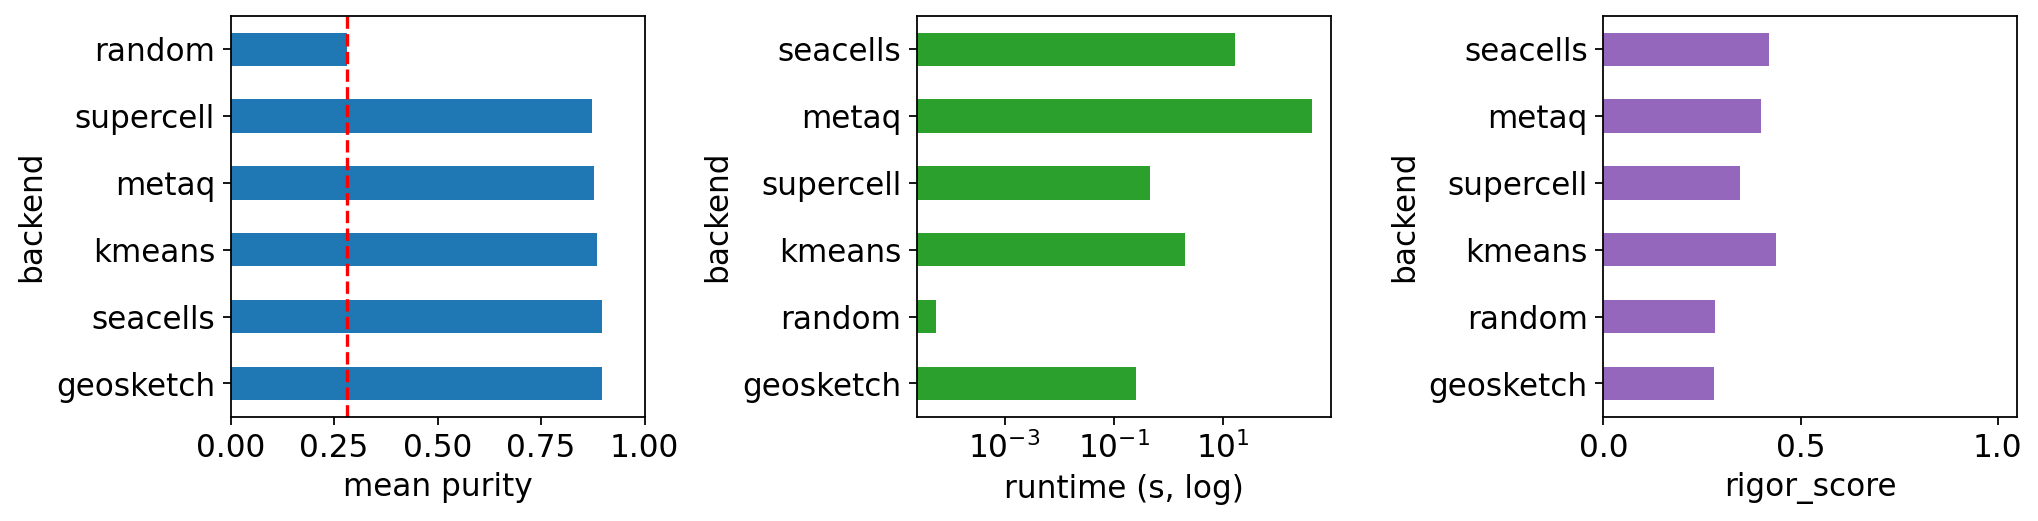

In [4]:
import matplotlib.pyplot as plt
ranked = bench.sort_values('mean_purity', ascending=True)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
ranked['mean_purity'].plot.barh(ax=axes[0], color='#1f77b4')
axes[0].set_xlabel('mean purity'); axes[0].set_xlim(0, 1)
axes[0].axvline(ranked['mean_purity']['random'], color='red', linestyle='--')

bench['runtime_s'].plot.barh(ax=axes[1], color='#2ca02c', logx=True)
axes[1].set_xlabel('runtime (s, log)')

bench['rigor_score'].plot.barh(ax=axes[2], color='#9467bd')
axes[2].set_xlabel('rigor_score'); axes[2].set_xlim(0, 1.05)
for ax in axes:
    ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 5. UMAP overlay grid

Project all six partitions back onto the source UMAP.

In [5]:
# Refit each backend keeping the MetaCell object so we can use the
# ov.pl.metacell_centroids helper for each panel.
backends = ['seacells', 'metaq', 'supercell', 'kmeans', 'random', 'geosketch']
fits = {}
for b in backends:
    extra = dict(train_epoch=80, warm_epochs=10, codebook_init='random') if b == 'metaq' else {}
    fits[b] = ov.single.MetaCell(
        adata.copy(), method=b, n_metacells=100,
        use_rep='X_pca',
        device='cpu' if b != 'metaq' else 'cuda',
        random_state=0, **extra,
    ).fit()
print('refit done')

Welcome to SEACells!


  0%|          | 0/3630 [00:00<?, ?it/s]

Parameter graph_construction = union being used to build KNN graph...


  0%|          | 0/3630 [00:00<?, ?it/s]

  0%|          | 0/3630 [00:00<?, ?it/s]

...

[Epoch 20] RNA: Loss Rec=0.9290 Loss Rec Q=0.9383 | Codebook: Loss C=0.0076


[Epoch 40] RNA: Loss Rec=0.9147 Loss Rec Q=0.9292 | Codebook: Loss C=0.0095


[Epoch 60] RNA: Loss Rec=0.9028 Loss Rec Q=0.9254 | Codebook: Loss C=0.0095


[Epoch 80] RNA: Loss Rec=0.8912 Loss Rec Q=0.9230 | Codebook: Loss C=0.0099


refit done


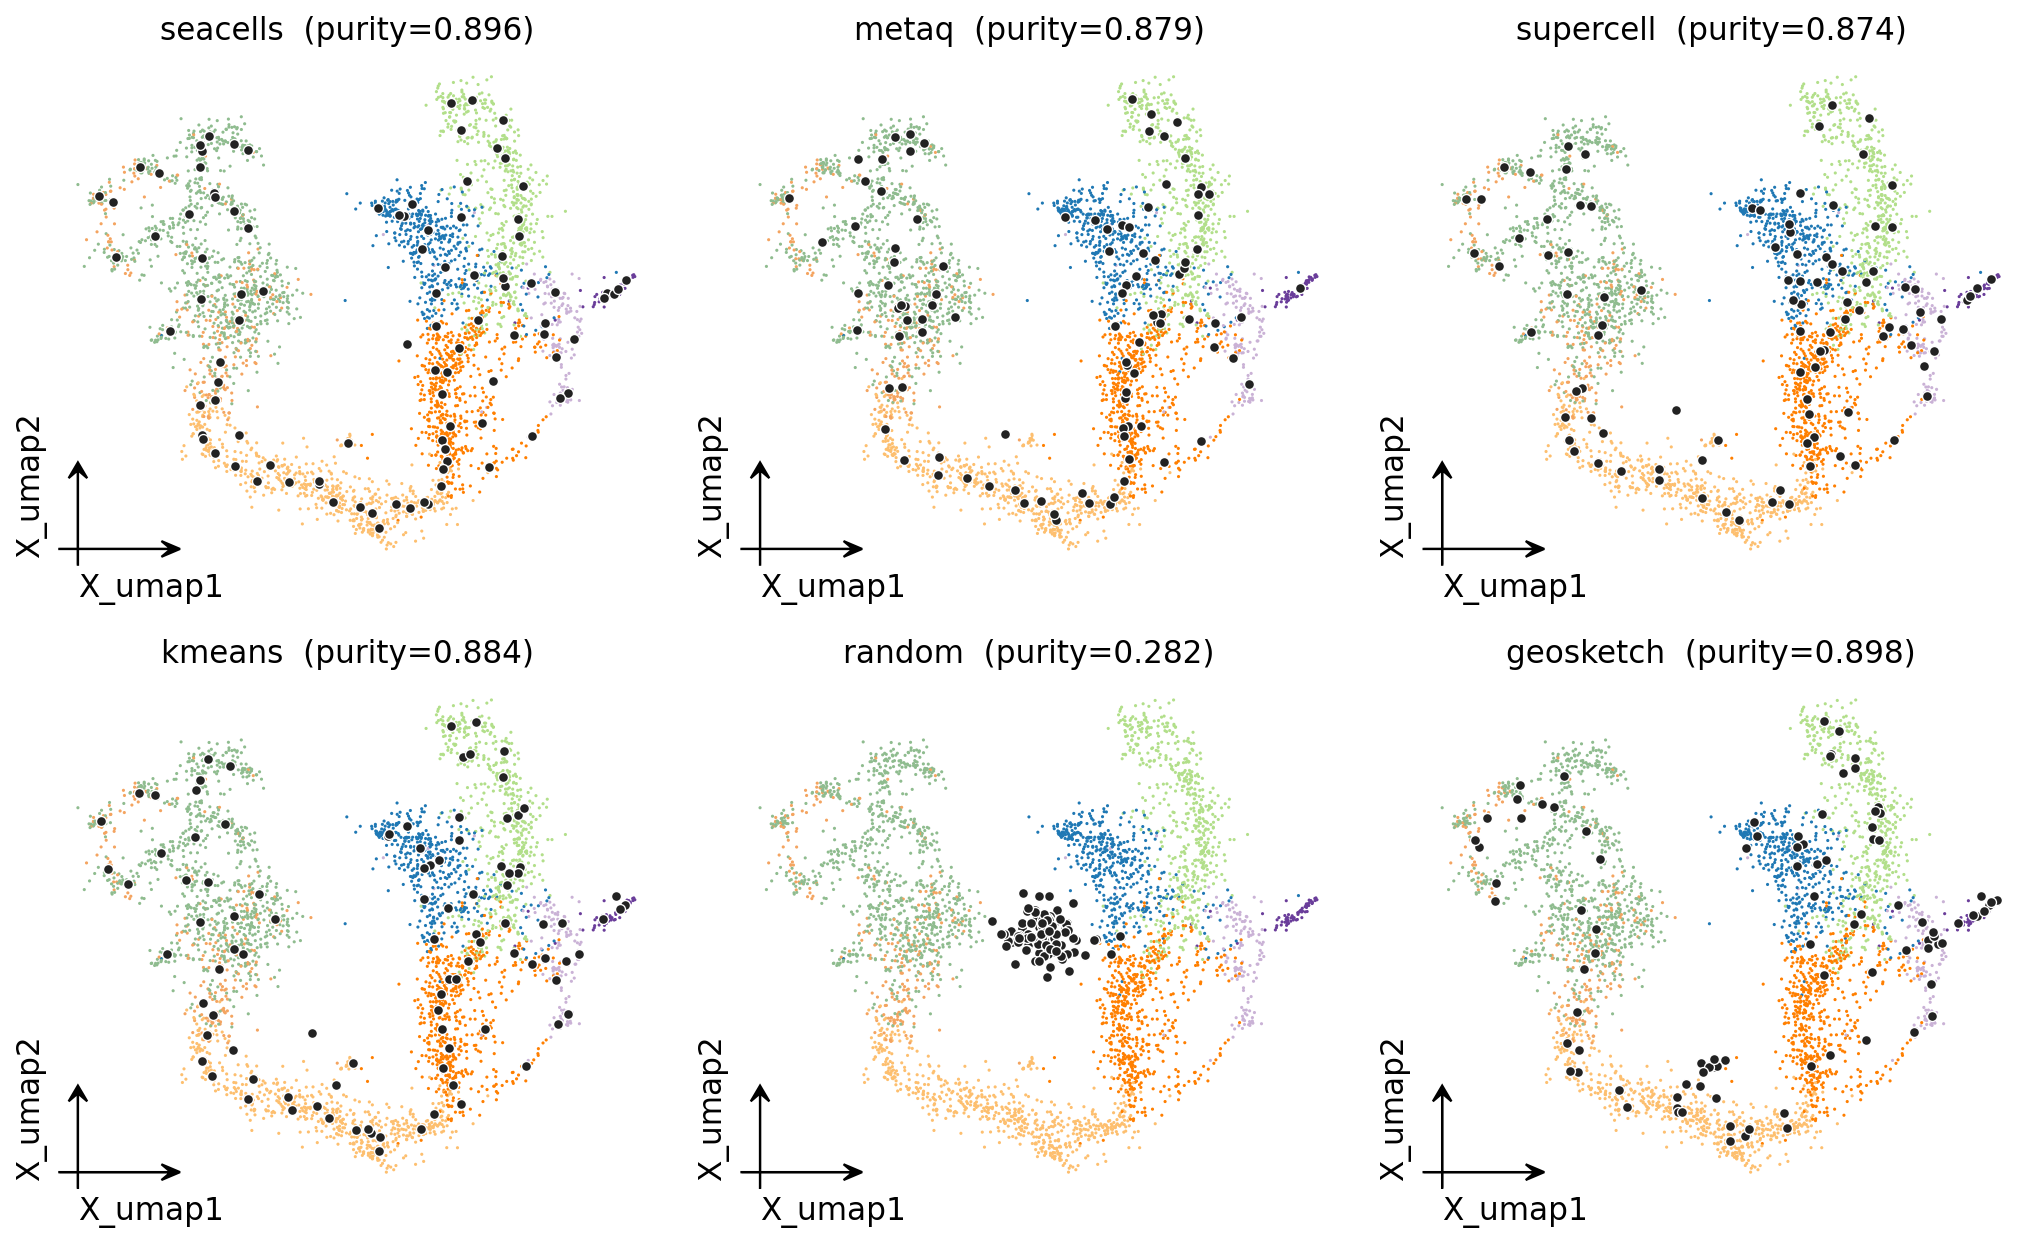

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, name in zip(axes.flatten(), backends):
    a = fits[name].adata
    ov.pl.embedding(a, basis='X_umap', color='clusters', ax=ax, show=False,
                    frameon='small',
                    title=f'{name}  (purity={bench.loc[name, "mean_purity"]:.3f})',
                    legend_loc=None, size=8)
    labels = fits[name]._fit_result.assignments
    pts = np.array([a.obsm['X_umap'][labels == u].mean(axis=0)
                    for u in np.unique(labels)])
    ax.scatter(pts[:, 0], pts[:, 1], s=20, c='#222',
               edgecolors='white', linewidths=0.6, zorder=5)
plt.tight_layout(); plt.show()

## 6. Purity histograms across backends

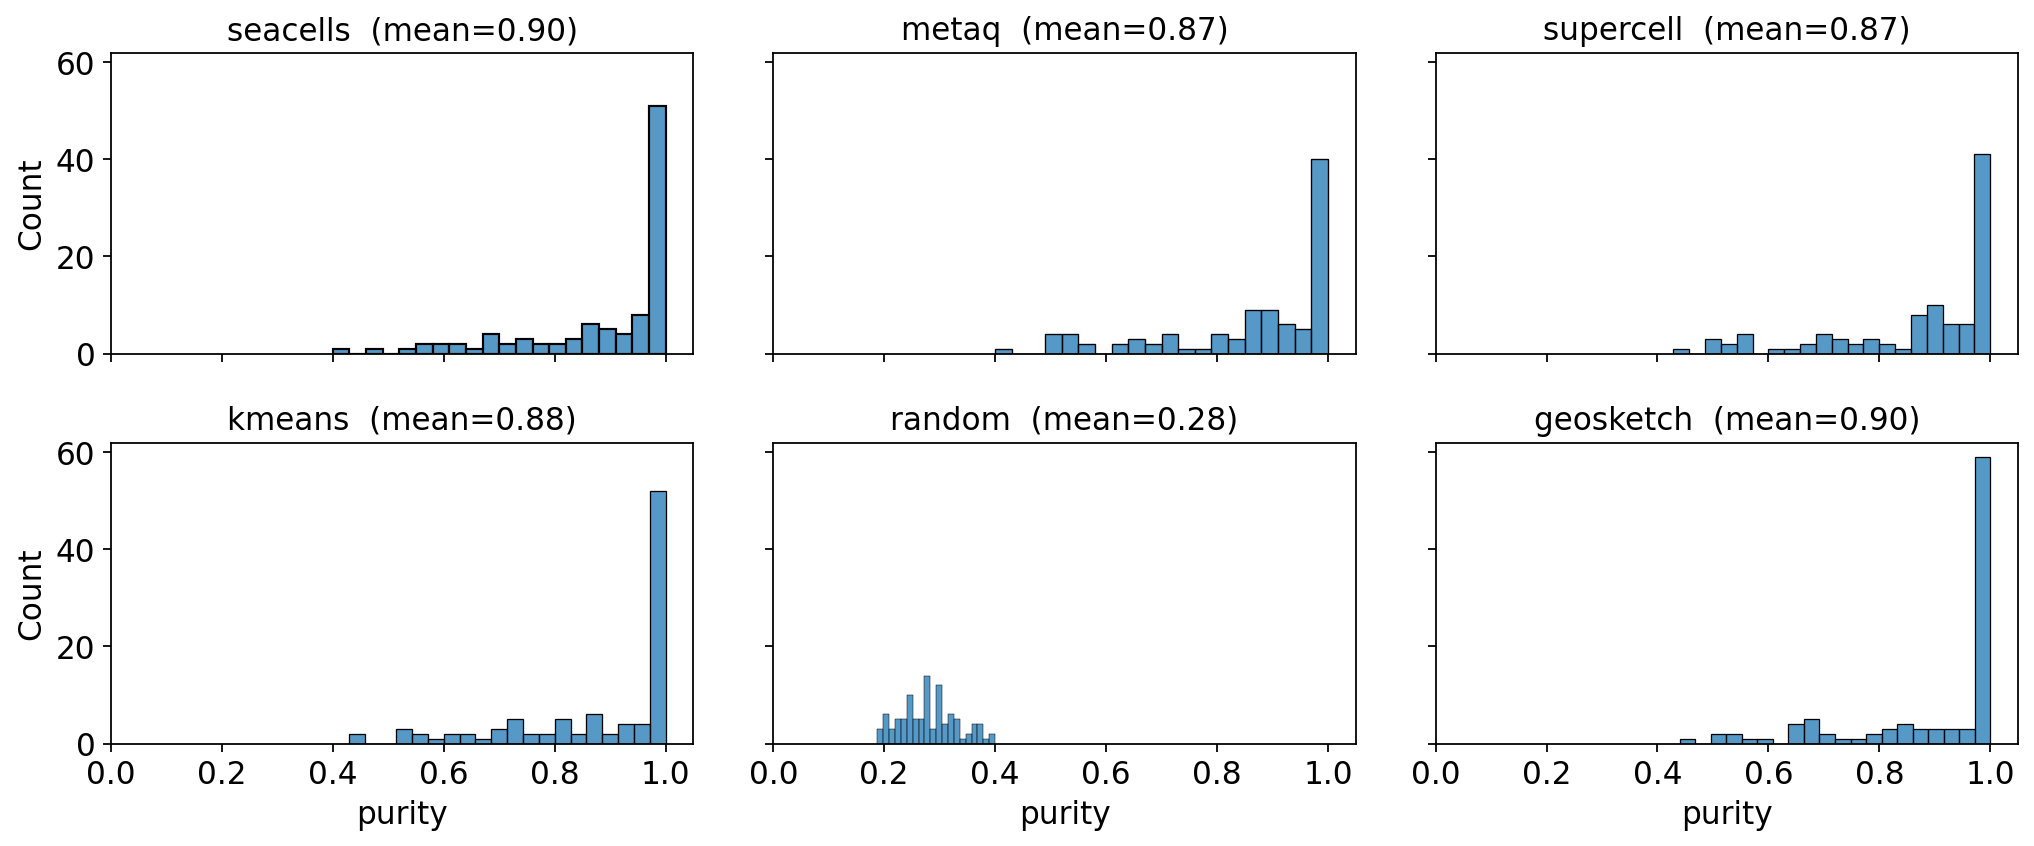

In [7]:
import seaborn as sns
fig, axes = plt.subplots(2, 3, figsize=(13, 5.5), sharex=True, sharey=True)
for ax, name in zip(axes.flatten(), backends):
    p = fits[name].compute_purity('clusters')['purity']
    sns.histplot(p, bins=20, ax=ax, color='#1f77b4')
    ax.set_title(f'{name}  (mean={p.mean():.2f})')
    ax.set_xlabel('purity'); ax.set_xlim(0, 1.05)
plt.tight_layout(); plt.show()

## 7. Marker recovery on the aggregated AnnData

Aggregate with each backend, then ask omicverse for the top marker per celltype
in the metacell AnnData.  The "right" markers (Ins1/Ins2 for Beta, Gcg for
Alpha, etc.) should pop out regardless of which backend you used.

In [8]:
top1 = {}
for b in backends:
    ad_mc = fits[b].predicted(method='hard', layer='counts', summary='sum',
                              celltype_label='clusters')
    ad_mc = ov.pp.preprocess(ad_mc, mode='shiftlog|pearson',
                              n_HVGs=min(2000, ad_mc.n_vars))
    counts = ad_mc.obs['clusters'].value_counts()
    keep = counts[counts >= 2].index.tolist()
    ad_mc = ad_mc[ad_mc.obs['clusters'].isin(keep)].copy()
    ad_mc.obs['clusters'] = ad_mc.obs['clusters'].astype('category')
    ov.single.find_markers(ad_mc, groupby='clusters', method='wilcoxon',
                           key_added='rank_genes_groups', pts=True, use_gpu=False)
    top1[b] = pd.DataFrame(ad_mc.uns['rank_genes_groups']['names']).iloc[0]
pd.DataFrame(top1)

🔍 [2026-05-19 17:49:27] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 2000/2000 genes are kept.
    Among 2000 genes, 2000 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['Ghrl']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 100 cells × 2,000 genes
   ✓ Runtime: 0.00s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100

✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 2,000 total (100.0%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_ra

✅ Done | 8 groups × 50 genes | corr: benjamini-hochberg | stored in adata.uns['rank_genes_groups']
🔍 [2026-05-19 17:49:27] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 2000/2000 genes are kept.
    Among 2000 genes, 2000 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 0 highly-expressed genes from normalization computation
   Excluded genes: []

✅ Count Normalization Completed Successfully!
   ✓ Processed: 100 cells × 2,000 genes
   ✓ Runtime: 0.00s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100

✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 2,000 total (100.0%)
   ✓ Results added to An


🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100

✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 2,000 total (100.0%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 0.02 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw coun

✅ Done | 8 groups × 50 genes | corr: benjamini-hochberg | stored in adata.uns['rank_genes_groups']
🔍 [2026-05-19 17:49:28] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 2000/2000 genes are kept.
    Among 2000 genes, 2000 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 0 highly-expressed genes from normalization computation
   Excluded genes: []

✅ Count Normalization Completed Successfully!
   ✓ Processed: 100 cells × 2,000 genes
   ✓ Runtime: 0.00s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100

✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 2,000 total (100.0%)
   ✓ Results added to An


🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100

✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 2,000 total (100.0%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 0.02 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw coun

,seacells,metaq,supercell,kmeans,random,geosketch
Alpha,Sphkap,Tmem27,Smarca1,Smarca1,Irx2,Zcchc18
Beta,Gng12,Mapt,Sytl4,Gng12,Sec61b,Sytl4
Delta,Rbp4,NaN,Rbp4,Scn3a,NaN,Sst
Ductal,Nudt19,Nudt19,Lurap1l,Nudt19,Spp1,Hpgd
Epsilon,Ghrl,Guca2b,Ghrl,Gm11837,NaN,Anpep
Ngn3 high EP,Numbl,Numbl,Cbfa2t3,Cbfa2t3,Cotl1,Smarcd2
Ngn3 low EP,Cited4,Cat,Grin3a,Angptl4,NaN,Atoh8
Pre-endocrine,Eif3e,Cystm1,Bax,Neat1,Fev,Fev


## 8. Recommendation table

A rough decision tree for this kind of dataset (mid-size mouse scRNA-seq
atlas, no batch / multi-modal complications):

| Downstream task | Pick |
|---|---|
| UMAP / Leiden / pretty plots | `kmeans` or `geosketch` — they're within ~5 % of SEACells on purity at 1–100× lower runtime |
| Differential expression / pseudobulk DESeq2 | `seacells` or `metaq` — proper aggregation preserves count semantics |
| Cell–cell communication (CellPhoneDB / LIANA) | `seacells` (soft membership matters) |
| Gene regulatory networks (SCENIC) | `seacells` or `metaq` |
| Atlas with new samples arriving over time | **`metaq`** — only backend with closed-form out-of-sample projection |
| Multi-million cell dataset | `metaq` (linear-time) or `mc2` (divide-and-conquer) |
| Quick sanity check that the pipeline works at all | `kmeans` first; `random` to confirm the floor |

**The most important rule**: include `random` in your benchmark.  If your
principled metacell pipeline isn't beating `random` on purity / rigor, you
have a bug, not metacells.